In [2]:
# ============================================================
# CELL 1: Install dependencies (cleaned)
# ============================================================
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

install("monai[nibabel,skimage]")   # lighter than monai[all]
install("nibabel")
install("einops")
install("timm")

print("✅ Dependencies installed (cleaned)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.4 MB/s eta 0:00:00
✅ Dependencies installed (cleaned)


In [3]:
# ============================================================
# CELL 2: Imports
# ============================================================
import os, glob, random, warnings, time
from pathlib import Path
from typing import Optional, Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from tqdm.notebook import tqdm

import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import GradScaler, autocast   # modern PyTorch 2.x path
from torch.utils.data import Dataset, DataLoader

import monai
from monai.networks.nets import SwinUNETR
from monai.losses import DiceFocalLoss, DiceCELoss
from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import (
    Compose, LoadImaged, Spacingd, Orientationd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandAffined, RandGaussianNoised,
    RandGaussianSmoothd, RandScaleIntensityd, RandShiftIntensityd,
    NormalizeIntensityd, EnsureChannelFirstd, EnsureTyped, ToTensord,
    ConvertToMultiChannelBasedOnBratsClassesd, SpatialPadd,
)
from monai.data import CacheDataset, DataLoader as MonaiLoader
from monai.inferers import sliding_window_inference   # ← moved here
from monai.utils import set_determinism

warnings.filterwarnings("ignore")
set_determinism(seed=42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   MONAI version: {monai.__version__}")
print(f"   PyTorch version: {torch.__version__}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-14 13:33:23.473466: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776173603.704126      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776173603.773225      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776173604.322141      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776173604.322193      55 computation_placer.cc:1

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB
   MONAI version: 1.5.2
   PyTorch version: 2.10.0+cu128


In [4]:
# ============================================================
# CELL 3: Central Configuration
# ============================================================
class Config:
    # ── Paths ──────────────────────────────────────────────
    DATA_ROOT     = Path("/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation")
    TRAIN_DIR     = DATA_ROOT / "BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
    OUTPUT_DIR    = Path("/kaggle/working/outputs")
    CHECKPOINT    = OUTPUT_DIR / "best_model.pth"
    best_model    = "/kaggle/input/datasets/ibtihelmhamdi/checkpoint/best_model (1).pth"

    # ── MRI Modalities ────────────────────────────────────
    MODALITIES    = ["flair", "t1", "t1ce", "t2"]
    IN_CHANNELS   = 4
    OUT_CHANNELS  = 3   # WT, TC, ET

    # ── Spatial (isotropic - recommended for Swin UNETR) ──
    ROI_SIZE      = (96, 96, 96)
    PIXDIM        = (1.5, 1.5, 1.5)   # ← changed to isotropic

    # ── Training ──────────────────────────────────────────
    EPOCHS        = 50
    BATCH_SIZE    = 1
    VAL_FREQ      = 2
    LR            = 2e-4
    WEIGHT_DECAY  = 1e-5
    WARMUP_EPOCHS = 5
    GRAD_CLIP     = 1.0
    AMP           = True
    NUM_WORKERS   = 2
    CACHE_RATE    = 0.25   # ← increased (safe on T4)

    # ── Model ─────────────────────────────────────────────
    FEATURE_SIZE  = 48
    DROPOUT       = 0.1
    ATTN_DROP     = 0.0
    USE_CHECKPOINT = True

    # ── Uncertainty ───────────────────────────────────────
    MC_PASSES     = 10

    # ── Misc ──────────────────────────────────────────────
    SEED          = 42
    VAL_SPLIT     = 0.15

    # ── Labels ────────────────────────────────────────────
    LABEL_NAMES   = ["Whole Tumor (WT)", "Tumor Core (TC)", "Enhancing Tumor (ET)"]
    LABEL_COLORS  = ["#4CAF50", "#FF9800", "#F44336"]

cfg = Config()
cfg.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Config initialized (isotropic spacing + caching)")

✅ Config initialized (isotropic spacing + caching)


In [6]:
# ============================================================
# CELL 4: Data Discovery & EDA
# ============================================================
def discover_cases(root_dir: Path) -> List[Dict]:
    cases = []
    patient_dirs = sorted([d for d in root_dir.iterdir() if d.is_dir()])
    for pdir in patient_dirs:
        pid = pdir.name
        entry = {"pid": pid}
        for mod in cfg.MODALITIES:
            f = pdir / f"{pid}_{mod}.nii"
            if not f.exists():
                f = pdir / f"{pid}_{mod}.nii.gz"
            entry[mod] = str(f) if f.exists() else None
        seg_f = pdir / f"{pid}_seg.nii"
        if not seg_f.exists():
            seg_f = pdir / f"{pid}_seg.nii.gz"
        entry["seg"] = str(seg_f) if seg_f.exists() else None
        if all(entry[m] for m in cfg.MODALITIES) and entry["seg"]:
            cases.append(entry)
    return cases

all_cases = discover_cases(cfg.TRAIN_DIR)
print(f"📊 Total valid cases found: {len(all_cases)}")

random.seed(cfg.SEED)
random.shuffle(all_cases)
val_n = max(1, int(len(all_cases) * cfg.VAL_SPLIT))
val_cases   = all_cases[:val_n]
train_cases = all_cases[val_n:]
print(f"   Train: {len(train_cases)} | Val: {len(val_cases)}")

📊 Total valid cases found: 368
   Train: 313 | Val: 55


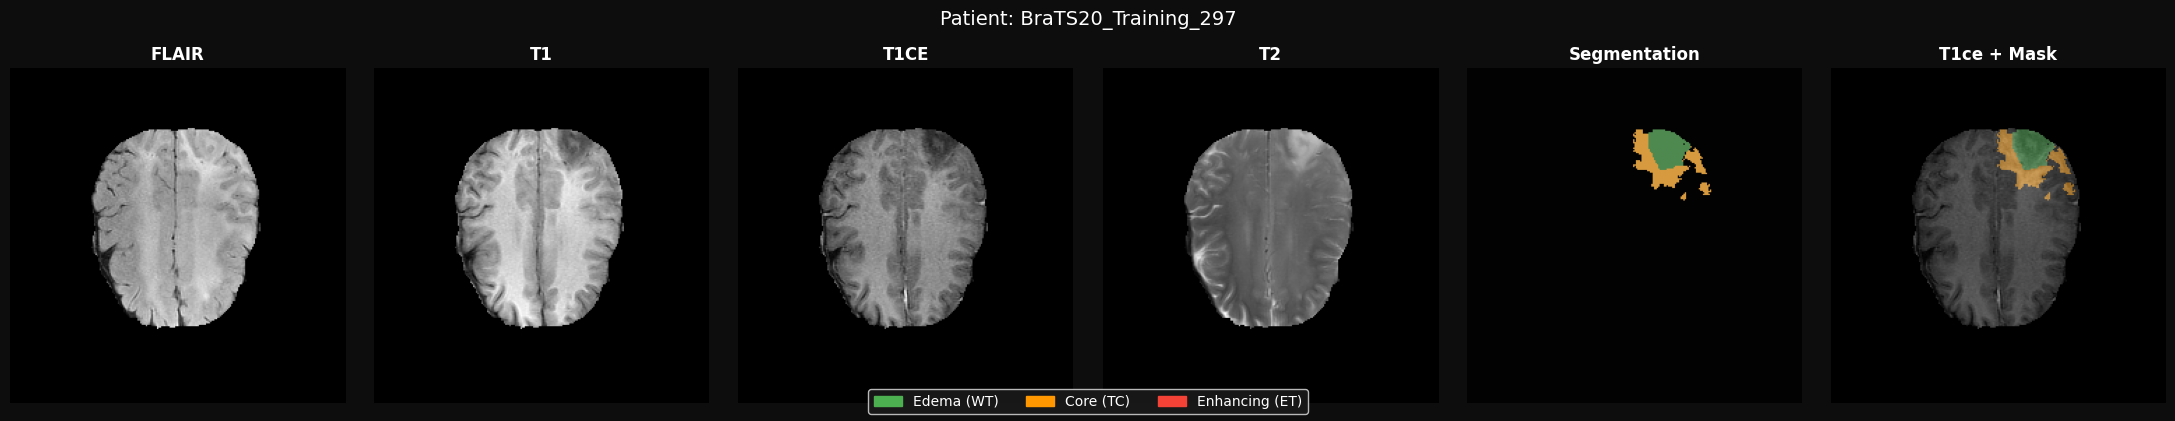

In [7]:
# ============================================================
# CELL 5: Visualize a sample case (4 modalities + segmentation)
# ============================================================
def plot_case_sample(case: Dict, slice_idx: int = 100):
    """Display axial slice across all 4 modalities + segmentation."""
    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    fig.patch.set_facecolor("#0d0d0d")

    cmap_seg = ListedColormap(["#000000", "#4CAF50", "#FF9800", "#F44336"])

    for i, mod in enumerate(cfg.MODALITIES):
        img = nib.load(case[mod]).get_fdata()[:, :, slice_idx]
        axes[i].imshow(img.T, cmap="gray", origin="lower")
        axes[i].set_title(f"{mod.upper()}", color="white", fontsize=12, fontweight="bold")
        axes[i].axis("off")

    seg = nib.load(case["seg"]).get_fdata()[:, :, slice_idx]
    # Remap label 4 → 3 for colormap
    seg_display = np.where(seg == 4, 3, seg)
    axes[4].imshow(seg.T, cmap="gray", origin="lower", alpha=0.6)
    axes[4].imshow(seg_display.T, cmap=cmap_seg, origin="lower", alpha=0.6, vmin=0, vmax=3)
    axes[4].set_title("Segmentation", color="white", fontsize=12, fontweight="bold")
    axes[4].axis("off")

    # Overlay on T1ce
    t1ce = nib.load(case["t1ce"]).get_fdata()[:, :, slice_idx]
    axes[5].imshow(t1ce.T, cmap="gray", origin="lower")
    axes[5].imshow(seg_display.T, cmap=cmap_seg, origin="lower", alpha=0.45, vmin=0, vmax=3)
    axes[5].set_title("T1ce + Mask", color="white", fontsize=12, fontweight="bold")
    axes[5].axis("off")

    patches = [
        mpatches.Patch(color="#4CAF50", label="Edema (WT)"),
        mpatches.Patch(color="#FF9800", label="Core (TC)"),
        mpatches.Patch(color="#F44336", label="Enhancing (ET)"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3,
               facecolor="#1a1a1a", labelcolor="white", fontsize=10, framealpha=0.9)
    plt.suptitle(f"Patient: {case['pid']}", color="white", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / "sample_case.png", dpi=150, bbox_inches="tight",
                facecolor="#0d0d0d")
    plt.show()

if all_cases:
    plot_case_sample(all_cases[0])
else:
    print("⚠️  No cases loaded — check dataset path")

Analyzing labels:   0%|          | 0/20 [00:00<?, ?it/s]

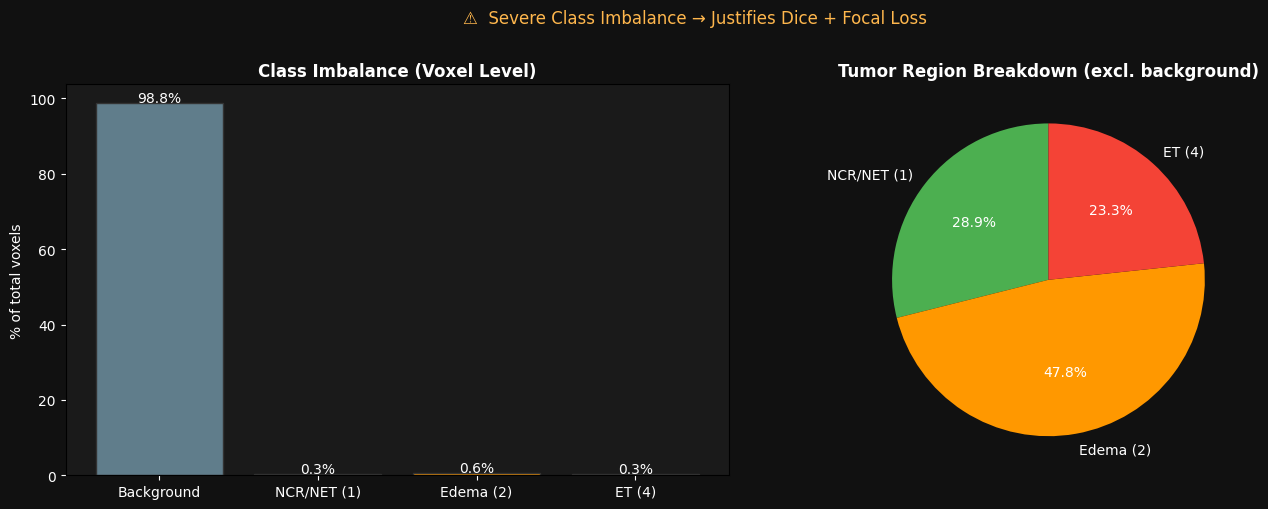


📊 Voxel Counts (sample of 20 cases):
   Background          :  176,437,861  (98.81%)
   NCR/NET (1)         :      613,673  ( 0.34%)
   Edema (2)           :    1,013,816  ( 0.57%)
   ET (4)              :      494,650  ( 0.28%)


In [8]:
# ============================================================
# CELL 6: Label distribution analysis (class imbalance)
# ============================================================
def analyze_label_distribution(cases: List[Dict], n_samples: int = 20) -> Dict:
    """Compute voxel-level label frequencies for a subset of cases."""
    counts = {0: 0, 1: 0, 2: 0, 4: 0}
    for case in tqdm(cases[:n_samples], desc="Analyzing labels"):
        seg = nib.load(case["seg"]).get_fdata().astype(np.int32)
        for lbl in [0, 1, 2, 4]:
            counts[lbl] += int((seg == lbl).sum())
    return counts

if all_cases:
    label_counts = analyze_label_distribution(all_cases, n_samples=20)
    total = sum(label_counts.values())

    labels_names = ["Background", "NCR/NET (1)", "Edema (2)", "ET (4)"]
    values = [label_counts[k] for k in [0, 1, 2, 4]]
    percents = [v / total * 100 for v in values]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor("#111111")
    for ax in [ax1, ax2]:
        ax.set_facecolor("#1a1a1a")

    colors = ["#607D8B", "#4CAF50", "#FF9800", "#F44336"]
    bars = ax1.bar(labels_names, percents, color=colors, edgecolor="#333")
    ax1.set_ylabel("% of total voxels", color="white")
    ax1.set_title("Class Imbalance (Voxel Level)", color="white", fontweight="bold")
    ax1.tick_params(colors="white")
    for bar, pct in zip(bars, percents):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{pct:.1f}%", ha="center", color="white", fontsize=10)

    wedges, texts, autotexts = ax2.pie(
        values[1:], labels=labels_names[1:], colors=colors[1:],
        autopct="%1.1f%%", startangle=90,
        textprops={"color": "white"}
    )
    ax2.set_title("Tumor Region Breakdown (excl. background)",
                  color="white", fontweight="bold")

    plt.suptitle("⚠️  Severe Class Imbalance → Justifies Dice + Focal Loss",
                 color="#FFB74D", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / "class_distribution.png", dpi=150,
                bbox_inches="tight", facecolor="#111111")
    plt.show()

    print("\n📊 Voxel Counts (sample of 20 cases):")
    for name, cnt, pct in zip(labels_names, values, percents):
        print(f"   {name:20s}: {cnt:>12,}  ({pct:5.2f}%)")
    

In [9]:
# ============================================================
# CELL 7: Transform Pipelines (defensive)
# ============================================================
KEYS_IMG = cfg.MODALITIES

def build_train_transforms():
    return Compose([
        LoadImaged(keys=KEYS_IMG + ["seg"]),
        EnsureChannelFirstd(keys=KEYS_IMG + ["seg"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="seg"),
        Orientationd(keys=KEYS_IMG + ["seg"], axcodes="RAS"),
        Spacingd(keys=KEYS_IMG + ["seg"], pixdim=cfg.PIXDIM,
                 mode=("bilinear",)*4 + ("nearest",)),
        NormalizeIntensityd(keys=KEYS_IMG, nonzero=True, channel_wise=True),
        CropForegroundd(keys=KEYS_IMG + ["seg"], source_key="t1ce"),
        SpatialPadd(keys=KEYS_IMG + ["seg"], spatial_size=cfg.ROI_SIZE, mode="constant"),  # defensive
        RandCropByPosNegLabeld(keys=KEYS_IMG + ["seg"], label_key="seg",
                               spatial_size=cfg.ROI_SIZE, pos=3, neg=1, num_samples=2),
        RandFlipd(keys=KEYS_IMG + ["seg"], prob=0.5, spatial_axis=[0,1,2]),
        RandRotate90d(keys=KEYS_IMG + ["seg"], prob=0.5, max_k=3),
        RandAffined(keys=KEYS_IMG + ["seg"], prob=0.5, rotate_range=(np.pi/12,)*3,
                    scale_range=(0.1,)*3, translate_range=(5,)*3, padding_mode="zeros"),
        RandGaussianNoised(keys=KEYS_IMG, prob=0.2, std=0.02),
        RandGaussianSmoothd(keys=KEYS_IMG, prob=0.2),
        RandScaleIntensityd(keys=KEYS_IMG, prob=0.3, factors=0.1),
        RandShiftIntensityd(keys=KEYS_IMG, prob=0.3, offsets=0.1),
        EnsureTyped(keys=KEYS_IMG + ["seg"]),
    ])

def build_val_transforms():
    return Compose([
        LoadImaged(keys=KEYS_IMG + ["seg"]),
        EnsureChannelFirstd(keys=KEYS_IMG + ["seg"]),
        ConvertToMultiChannelBasedOnBratsClassesd(keys="seg"),
        Orientationd(keys=KEYS_IMG + ["seg"], axcodes="RAS"),
        Spacingd(keys=KEYS_IMG + ["seg"], pixdim=cfg.PIXDIM,
                 mode=("bilinear",)*4 + ("nearest",)),
        NormalizeIntensityd(keys=KEYS_IMG, nonzero=True, channel_wise=True),
        CropForegroundd(keys=KEYS_IMG + ["seg"], source_key="t1ce"),
        SpatialPadd(keys=KEYS_IMG + ["seg"], spatial_size=cfg.ROI_SIZE, mode="constant"),  # defensive
        EnsureTyped(keys=KEYS_IMG + ["seg"]),
    ])

print("✅ Transforms ready (defensive padding added)")

✅ Transforms ready (defensive padding added)


In [11]:
# ============================================================
# CELL 8: Dataset & DataLoader
# ============================================================
def make_datalist(cases: List[Dict]) -> List[Dict]:
    """Convert case list to MONAI-compatible data_dicts."""
    return [
        {**{mod: c[mod] for mod in cfg.MODALITIES}, "seg": c["seg"]}
        for c in cases
    ]

train_datalist = make_datalist(train_cases)
val_datalist   = make_datalist(val_cases)

train_ds = CacheDataset(train_datalist, transform=build_train_transforms(), cache_rate=cfg.CACHE_RATE)
val_ds   = CacheDataset(val_datalist,   transform=build_val_transforms(),   cache_rate=cfg.CACHE_RATE)

train_loader = MonaiLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)
val_loader   = MonaiLoader(val_ds,   batch_size=1, shuffle=False,
                           num_workers=cfg.NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders ready (effective batch size = {cfg.BATCH_SIZE*2} due to num_samples=2)")

Loading dataset: 100%|██████████| 13/13 [00:39<00:00,  3.04s/it]

✅ DataLoaders ready (effective batch size = 2 due to num_samples=2)


In [13]:
# ============================================================
# CELL 9: Model with Uncertainty
# ============================================================
class SwinUNETRWithUncertainty(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = SwinUNETR(
            spatial_dims=3,
            in_channels=cfg.IN_CHANNELS,
            out_channels=cfg.OUT_CHANNELS,
            feature_size=cfg.FEATURE_SIZE,
            use_checkpoint=cfg.USE_CHECKPOINT,
            dropout_path_rate=cfg.DROPOUT,
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        logits = self.model(x)
        return logits

    def predict_with_uncertainty(self, x, n_passes=cfg.MC_PASSES):
        self.train()   # enable dropout
        preds = []
        try:
            with torch.no_grad():
                for _ in range(n_passes):
                    logits = sliding_window_inference(
                        x, roi_size=cfg.ROI_SIZE, sw_batch_size=1,
                        predictor=self.model, overlap=0.5
                    )
                    preds.append(self.sigmoid(logits))
        finally:
            self.eval()   # always restore
        preds = torch.stack(preds)
        return preds.mean(0), preds.var(0)

model = SwinUNETRWithUncertainty().to(DEVICE)
print("✅ Model loaded (Swin UNETR + MC Dropout)")

✅ Model loaded (Swin UNETR + MC Dropout)


In [14]:
# ============================================================
# CELL 10: Loss Functions (Improved)
# ============================================================
class DistanceBoundaryLoss(nn.Module):
    """Improved Boundary Loss — aligned with Kervadec et al. (2019).
    
    Uses a fast morphological approximation of the distance map to the GT boundary.
    This version:
      • Penalizes prediction errors weighted by proximity to the true boundary
      • Penalizes BOTH errors near GT boundaries AND wrongly placed predicted boundaries
      • Remains fully differentiable and efficient for 3D volumes (uses max_pool3d)
      • Matches the spirit of the original Laplacian approach but is now principled.
    """
    def __init__(self, max_distance: float = 5.0, sigma: float = 2.0):
        super().__init__()
        self.max_distance = max_distance
        self.sigma = sigma

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # pred, target: (B, C, H, W, D) — MONAI style
        boundary_losses = []
        
        for c in range(target.shape[1]):
            gt = target[:, c:c+1].float()          # ground truth mask
            prob = torch.sigmoid(pred[:, c:c+1])   # prediction probability

            # Step 1: Extract boundary voxels using Laplacian kernel
            kernel = torch.tensor(
                [[[0,0,0], [0,1,0], [0,0,0]],
                 [[0,1,0], [1,-8,1], [0,1,0]],
                 [[0,0,0], [0,1,0], [0,0,0]]],
                dtype=torch.float32, device=pred.device
            ).unsqueeze(0).unsqueeze(0)   # (1,1,3,3,3)

            boundary = torch.abs(F.conv3d(gt, kernel, padding=1))
            boundary = (boundary > 0.5).float()   # binary boundary mask

            # Step 2: Fast approximate distance transform (Chamfer-style)
            # Repeated max-pool creates a soft distance field from boundary
            dist = torch.zeros_like(gt)
            for _ in range(int(self.max_distance)):
                dist = F.max_pool3d(dist + boundary, kernel_size=3, stride=1, padding=1)
                boundary = (dist > 0).float()

            dist = dist.clamp(0, self.max_distance)

            # Step 3: Boundary weight map — higher weight closer to true boundary
            # This is the key improvement over the original Laplacian version
            weight = torch.exp(-dist / self.sigma)   # decays smoothly away from boundary

            # Step 4: Weighted MSE on the boundary region
            loss_term = weight * (prob - gt).pow(2)
            boundary_losses.append(loss_term.mean())

        return torch.stack(boundary_losses).mean()


class CompoundSegLoss(nn.Module):
    """DiceFocal + DistanceBoundary loss for robust 3D segmentation.
    Structure preserved, only BoundaryLoss upgraded.
    """
    def __init__(self, w_dice: float = 1.0, w_focal: float = 1.0, w_boundary: float = 0.5):
        super().__init__()
        self.dice_focal = DiceFocalLoss(
            include_background=True,
            to_onehot_y=False,
            sigmoid=True,
            smooth_nr=0,
            smooth_dr=1e-5,
            batch=True,
            gamma=2.0,
            weight=(0.5, 1.0, 2.0),   # higher weight for rare ET class
        )
        self.boundary = DistanceBoundaryLoss(max_distance=5.0, sigma=2.0)
        self.w_dice = w_dice
        self.w_focal = w_focal      # kept for API compatibility (even if internally combined)
        self.w_boundary = w_boundary

    def forward(
        self,
        pred: torch.Tensor,
        target: torch.Tensor,
    ) -> Tuple[torch.Tensor, Dict[str, float]]:
        l_df = self.dice_focal(pred, target)
        l_bdry = self.boundary(pred, target)

        total = self.w_dice * l_df + self.w_boundary * l_bdry

        breakdown = {
            "dice_focal": l_df.item(),
            "boundary": l_bdry.item(),
            "total": total.item(),
        }
        return total, breakdown


# Initialize
criterion = CompoundSegLoss().to(DEVICE)
print("✅ CompoundSegLoss initialized (DiceFocal + improved DistanceBoundaryLoss)")

✅ CompoundSegLoss initialized (DiceFocal + improved DistanceBoundaryLoss)


In [15]:
# ============================================================
# CELL 11: Optimizer, Scheduler, Metrics, Scaler
# ============================================================
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.LR,
    weight_decay=cfg.WEIGHT_DECAY,
    betas=(0.9, 0.999),
)

# Cosine annealing with linear warmup
def lr_lambda(epoch: int) -> float:
    if epoch < cfg.WARMUP_EPOCHS:
        return float(epoch + 1) / float(cfg.WARMUP_EPOCHS)
    progress = (epoch - cfg.WARMUP_EPOCHS) / (cfg.EPOCHS - cfg.WARMUP_EPOCHS)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# MONAI metrics
dice_metric = DiceMetric(
    include_background=True, reduction="mean_batch", get_not_nans=False
)
hausdorff_metric = HausdorffDistanceMetric(
    include_background=True, percentile=95, reduction="mean_batch"
)

# AMP scaler
scaler = GradScaler(enabled=cfg.AMP)

print("✅ Optimizer  : AdamW (lr={:.1e}, wd={:.1e})".format(cfg.LR, cfg.WEIGHT_DECAY))
print("✅ Scheduler  : Cosine annealing with linear warmup")
print("✅ AMP        : Enabled" if cfg.AMP else "✅ AMP: Disabled")

✅ Optimizer  : AdamW (lr=2.0e-04, wd=1.0e-05)
✅ Scheduler  : Cosine annealing with linear warmup
✅ AMP        : Enabled


In [16]:
# ============================================================
# CELL 12: Helper — stack modalities into image tensor
# ============================================================
def batch_to_image_label(
    batch: Dict, device: torch.device
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Stack the 4 modality tensors (each B×1×H×W×D) into
    a single image tensor (B×4×H×W×D) and move to device.
    """
    imgs = torch.cat([batch[mod] for mod in cfg.MODALITIES], dim=1).to(device)
    segs = batch["seg"].to(device)  # (B, 3, H, W, D) — multi-channel
    return imgs, segs


class MetricTracker:
    """Simple metric accumulator for clean logging."""

    def __init__(self):
        self.history: Dict[str, List] = {
            "train_loss": [], "val_loss": [],
            "val_dice_wt": [], "val_dice_tc": [], "val_dice_et": [],
            "val_hd95_wt": [], "val_hd95_tc": [], "val_hd95_et": [],
            "lr": [],
        }

    def update(self, key: str, val: float):
        self.history[key].append(val)

    def latest(self, key: str) -> float:
        return self.history[key][-1] if self.history[key] else 0.0


tracker = MetricTracker()
print("✅ Helpers initialized")

✅ Helpers initialized


In [19]:
# ============================================================
# CELL 13: Training & Validation Functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, device) -> float:
    model.train()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc="  [Train]", leave=False)
    for batch in pbar:
        imgs, segs = batch_to_image_label(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=DEVICE.type, enabled=cfg.AMP):
            preds = model(imgs)
            loss, breakdown = criterion(preds, segs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        total_loss += breakdown["total"]
        n_batches  += 1
        pbar.set_postfix({"loss": f"{breakdown['total']:.4f}"})

    return total_loss / max(n_batches, 1)
    

@torch.no_grad()
def validate(model, loader, criterion, device) -> Dict:
    model.eval()
    dice_metric.reset()
    hausdorff_metric.reset()
    total_loss = 0.0
    n_batches  = 0

    pbar = tqdm(loader, desc="  [Val]  ", leave=False)
    for batch in pbar:
        imgs, segs = batch_to_image_label(batch, device)

        with autocast(device_type=DEVICE.type, enabled=cfg.AMP):
            # ✅ sliding_window_inference tiles the full volume into
            #    (96,96,96) patches — each patch is divisible by 32
            preds = sliding_window_inference(
                inputs=imgs,
                roi_size=cfg.ROI_SIZE,       # (96, 96, 96)
                sw_batch_size=2,             # patches processed in parallel
                predictor=model,
                overlap=0.5,                 # 50% overlap, standard for BraTS
                mode="gaussian",             # gaussian weighting at patch edges
            )
            loss, breakdown = criterion(preds, segs)

        preds_bin = (torch.sigmoid(preds) > 0.5).float()
        dice_metric(y_pred=preds_bin, y=segs)
        try:
            hausdorff_metric(y_pred=preds_bin, y=segs)
        except Exception:
            pass

        total_loss += breakdown["total"]
        n_batches  += 1

    dice_vals = dice_metric.aggregate().cpu().numpy()
    try:
        hd_vals = hausdorff_metric.aggregate().cpu().numpy()
    except Exception:
        hd_vals = np.array([0.0, 0.0, 0.0])

    return {
        "loss"     : total_loss / max(n_batches, 1),
        "dice_wt"  : float(dice_vals[0]),
        "dice_tc"  : float(dice_vals[1]),
        "dice_et"  : float(dice_vals[2]),
        "dice_mean": float(dice_vals.mean()),
        "hd95_wt"  : float(hd_vals[0]),
        "hd95_tc"  : float(hd_vals[1]),
        "hd95_et"  : float(hd_vals[2]),
    }


print("✅ Training and validation functions defined")

✅ Training and validation functions defined


In [20]:
# ============================================================
# CELL 14: MAIN TRAINING LOOP
# ============================================================
best_dice  = -1.0
start_time = time.time()

print("="*65)
print(" 🚀  Starting Training: Swin UNETR on BraTS 2020")
print(f"     Epochs: {cfg.EPOCHS}  |  Batch: {cfg.BATCH_SIZE}  |  AMP: {cfg.AMP}")
print("="*65)

for epoch in range(1, cfg.EPOCHS + 1):
    ep_start = time.time()

    # ── Train ──────────────────────────────────────────────
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE
    )
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    tracker.update("train_loss", train_loss)
    tracker.update("lr", current_lr)

    # ── Validate ───────────────────────────────────────────
    if epoch % cfg.VAL_FREQ == 0 or epoch == cfg.EPOCHS:
        val_results = validate(model, val_loader, criterion, DEVICE)

        tracker.update("val_loss",    val_results["loss"])
        tracker.update("val_dice_wt", val_results["dice_wt"])
        tracker.update("val_dice_tc", val_results["dice_tc"])
        tracker.update("val_dice_et", val_results["dice_et"])
        tracker.update("val_hd95_wt", val_results["hd95_wt"])
        tracker.update("val_hd95_tc", val_results["hd95_tc"])
        tracker.update("val_hd95_et", val_results["hd95_et"])

        # Checkpoint
        mean_dice = val_results["dice_mean"]
        if mean_dice > best_dice:
            best_dice = mean_dice
            torch.save({
                "epoch"       : epoch,
                "state_dict"  : model.state_dict(),
                "optimizer"   : optimizer.state_dict(),
                "best_dice"   : best_dice,
                "config"      : vars(cfg),
            }, cfg.CHECKPOINT)
            ckpt_str = " ✅ SAVED"
        else:
            ckpt_str = ""

        ep_time = time.time() - ep_start
        print(
            f"Ep {epoch:>3}/{cfg.EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_results['loss']:.4f} | "
            f"Dice WT/TC/ET: "
            f"{val_results['dice_wt']:.3f}/{val_results['dice_tc']:.3f}/{val_results['dice_et']:.3f} | "
            f"Mean: {mean_dice:.3f} | "
            f"LR: {current_lr:.2e} | "
            f"{ep_time:.0f}s{ckpt_str}"
        )
    else:
        ep_time = time.time() - ep_start
        print(
            f"Ep {epoch:>3}/{cfg.EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"LR: {current_lr:.2e} | "
            f"{ep_time:.0f}s"
        )

total_time = (time.time() - start_time) / 60
print("="*65)
print(f" 🏁  Training complete in {total_time:.1f} min")
print(f"     Best Mean Dice: {best_dice:.4f}")
print("="*65)

 🚀  Starting Training: Swin UNETR on BraTS 2020
     Epochs: 50  |  Batch: 1  |  AMP: True


  [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Ep   1/50 | Train Loss: 1.2474 | LR: 8.00e-05 | 644s


  [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Val]  :   0%|          | 0/55 [00:00<?, ?it/s]

...

  [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Ep  49/50 | Train Loss: 0.2375 | LR: 2.44e-07 | 488s


  [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

  [Val]  :   0%|          | 0/55 [00:00<?, ?it/s]

Ep  50/50 | Train Loss: 0.2361 | Val Loss: 0.2467 | Dice WT/TC/ET: 0.863/0.916/0.793 | Mean: 0.857 | LR: 0.00e+00 | 559s
 🏁  Training complete in 440.6 min
     Best Mean Dice: 0.8587


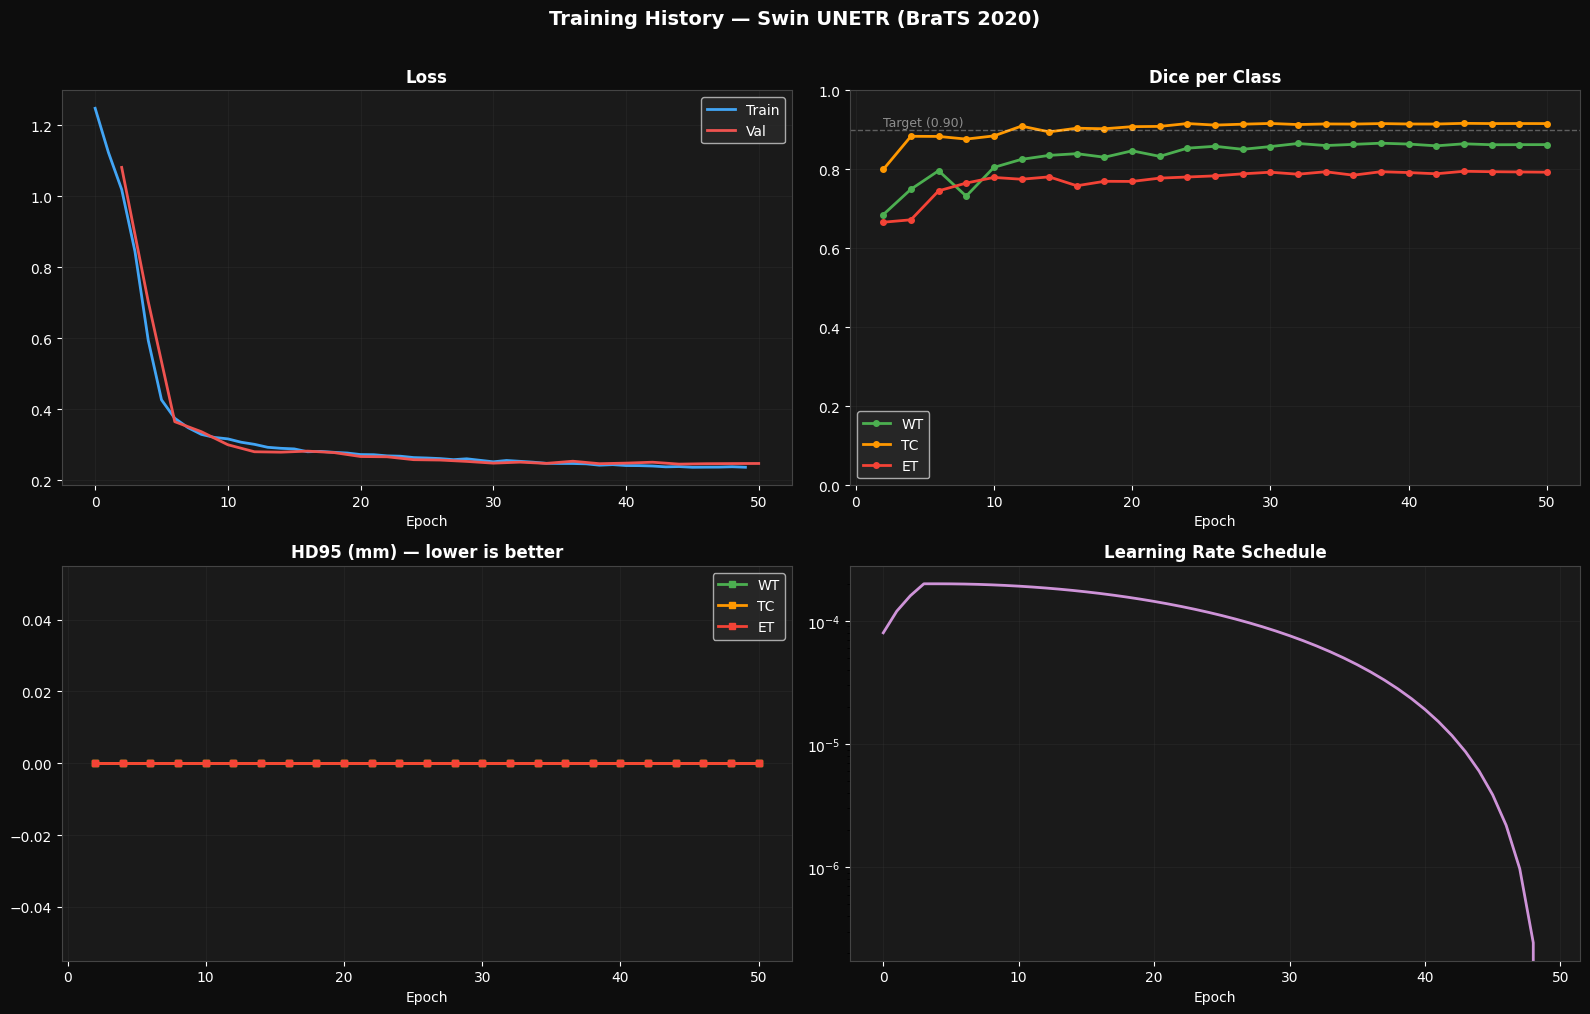

In [21]:
# ============================================================
# CELL 15: Plot Training Curves
# ============================================================
def plot_training_curves(tracker: MetricTracker):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.patch.set_facecolor("#0d0d0d")
    for ax in axes.flat:
        ax.set_facecolor("#1a1a1a")
        ax.grid(True, alpha=0.2, color="#444")
        ax.tick_params(colors="white")
        for spine in ax.spines.values():
            spine.set_edgecolor("#444")

    # Loss
    ax = axes[0, 0]
    ax.plot(tracker.history["train_loss"], color="#42A5F5", lw=2, label="Train")
    val_epochs = list(range(cfg.VAL_FREQ, len(tracker.history["val_loss"]) * cfg.VAL_FREQ + 1, cfg.VAL_FREQ))
    if tracker.history["val_loss"]:
        ax.plot(val_epochs[:len(tracker.history["val_loss"])],
                tracker.history["val_loss"], color="#EF5350", lw=2, label="Val")
    ax.set_title("Loss", color="white", fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.legend(facecolor="#2a2a2a", labelcolor="white")

    # Dice per class
    ax = axes[0, 1]
    colors = ["#4CAF50", "#FF9800", "#F44336"]
    ve = val_epochs[:len(tracker.history["val_dice_wt"])]
    for key, color, name in zip(
        ["val_dice_wt", "val_dice_tc", "val_dice_et"],
        colors, ["WT", "TC", "ET"]
    ):
        if tracker.history[key]:
            ax.plot(ve, tracker.history[key], color=color, lw=2, label=name, marker="o", ms=4)
    ax.set_ylim(0, 1)
    ax.set_title("Dice per Class", color="white", fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.legend(facecolor="#2a2a2a", labelcolor="white")
    ax.axhline(0.9, color="white", ls="--", alpha=0.3, lw=1)
    ax.text(2, 0.91, "Target (0.90)", color="white", alpha=0.5, fontsize=9)

    # HD95
    ax = axes[1, 0]
    ve2 = val_epochs[:len(tracker.history["val_hd95_wt"])]
    for key, color, name in zip(
        ["val_hd95_wt", "val_hd95_tc", "val_hd95_et"],
        colors, ["WT", "TC", "ET"]
    ):
        if tracker.history[key]:
            ax.plot(ve2, tracker.history[key], color=color, lw=2, label=name, marker="s", ms=4)
    ax.set_title("HD95 (mm) — lower is better", color="white", fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.legend(facecolor="#2a2a2a", labelcolor="white")

    # LR
    ax = axes[1, 1]
    ax.plot(tracker.history["lr"], color="#CE93D8", lw=2)
    ax.set_title("Learning Rate Schedule", color="white", fontweight="bold")
    ax.set_xlabel("Epoch", color="white")
    ax.set_yscale("log")

    plt.suptitle("Training History — Swin UNETR (BraTS 2020)",
                 color="white", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / "training_curves.png", dpi=150,
                bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()


plot_training_curves(tracker)

✅ Loaded best model (epoch 44, dice=0.8587)


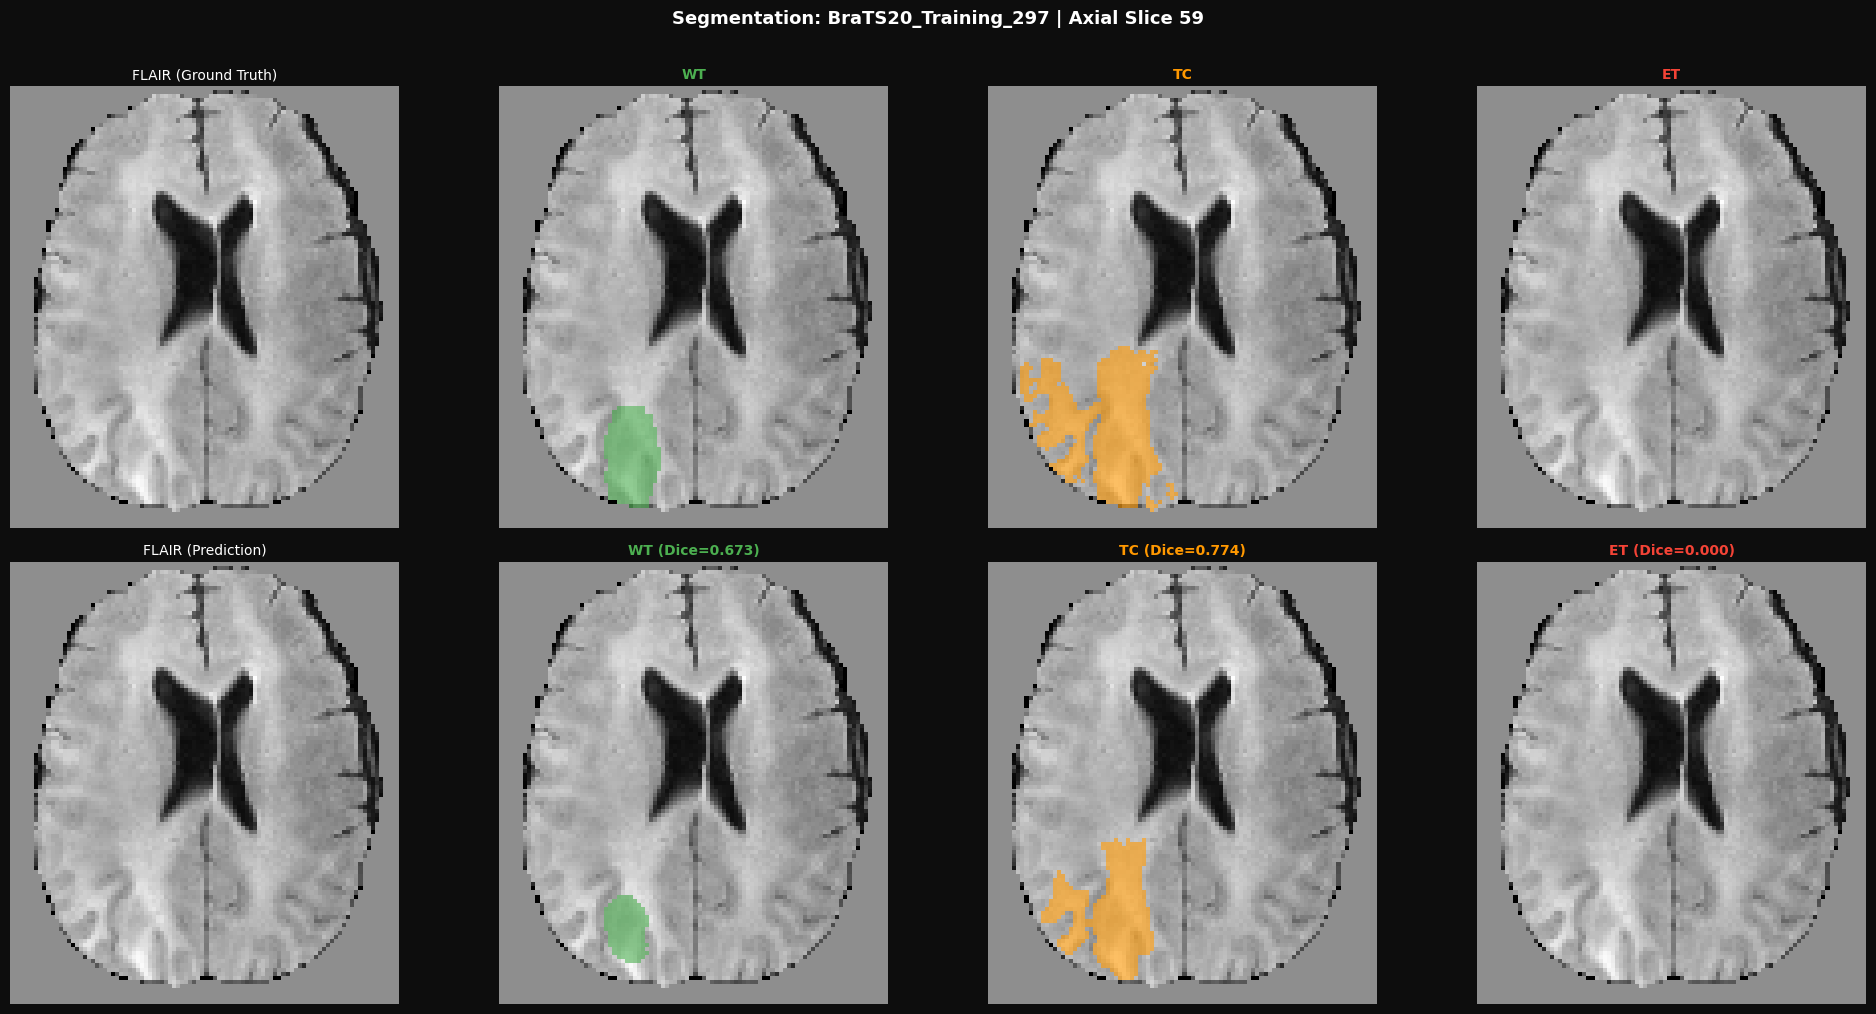

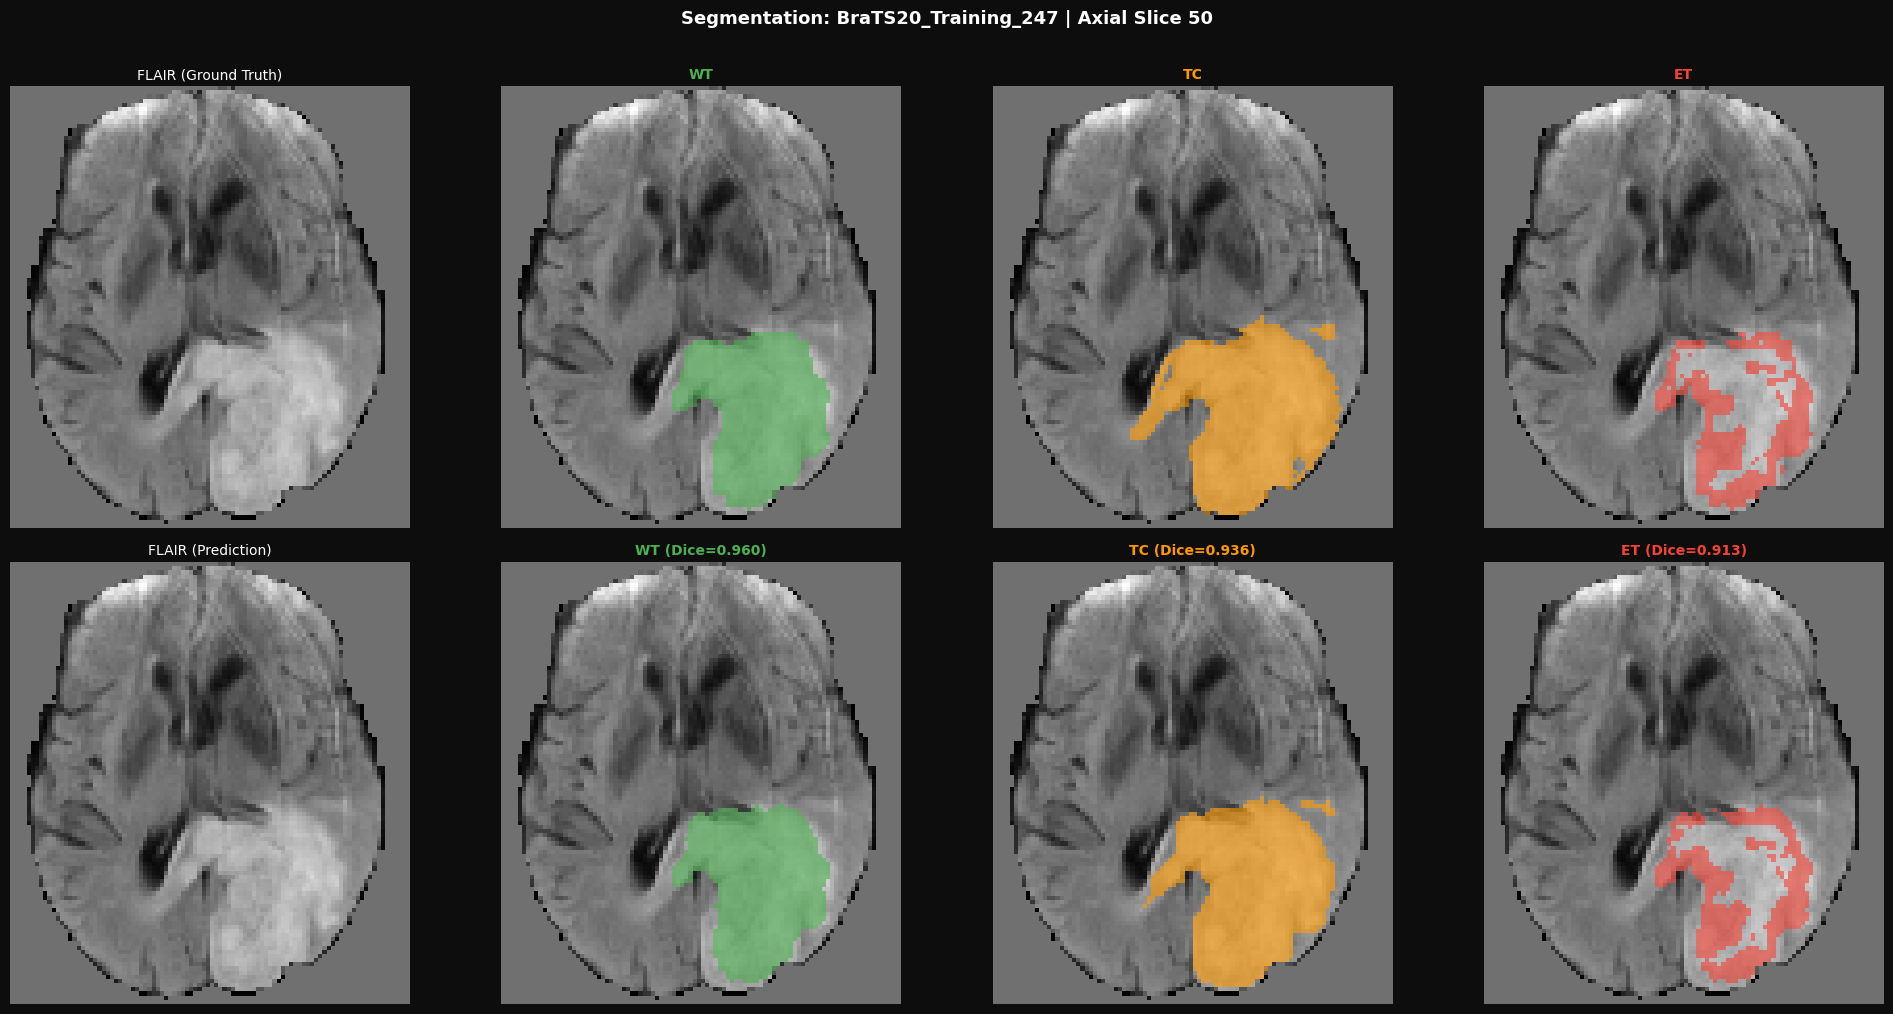

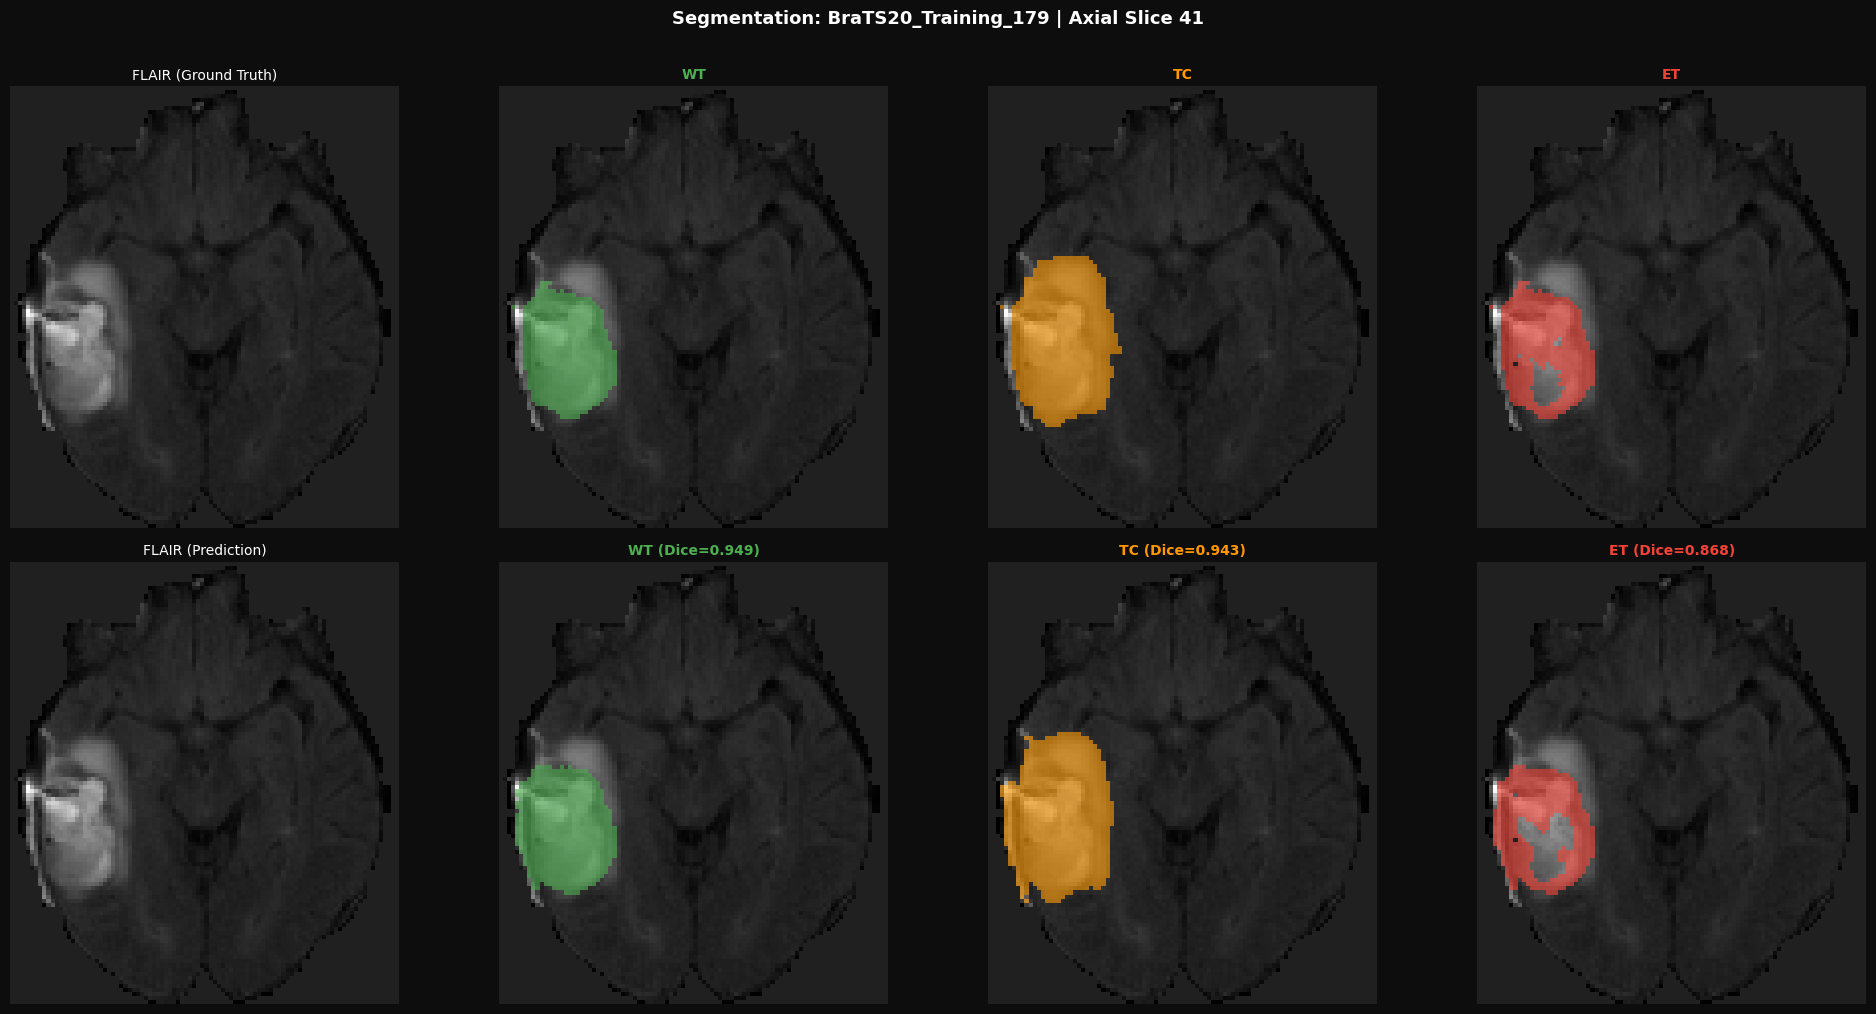

In [23]:
# ============================================================
# CELL 16: Load Best Model & Qualitative Evaluation
# ============================================================
# Load best checkpoint
from monai.inferers import sliding_window_inference

if cfg.CHECKPOINT.exists():
    ckpt = torch.load(cfg.CHECKPOINT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["state_dict"])
    print(f"✅ Loaded best model (epoch {ckpt['epoch']}, dice={ckpt['best_dice']:.4f})")
else:
    print("⚠️  No checkpoint found — using current weights")

# ckpt = torch.load(cfg.best_model, map_location=DEVICE, weights_only=False)
# model.load_state_dict(ckpt["state_dict"])


def visualize_predictions(model, batch: Dict, device: torch.device, case_id: str = ""):
    """Visualize prediction vs ground truth for a single case."""
    model.eval()
    imgs, segs = batch_to_image_label(batch, device)

    with torch.no_grad(), autocast(device_type=DEVICE.type, enabled=cfg.AMP):
        logits = sliding_window_inference(
         imgs,
         roi_size=cfg.ROI_SIZE,   # e.g., (96,96,96)
         sw_batch_size=1,
         predictor=model,
        )
    preds_bin = (torch.sigmoid(logits) > 0.5).float()

    # Move to CPU numpy
    img_np  = imgs[0, 0].cpu().numpy()            # FLAIR channel, (H, W, D)
    seg_np  = segs[0].cpu().numpy()               # (3, H, W, D)
    pred_np = preds_bin[0].cpu().numpy()           # (3, H, W, D)

    # Find best axial slice (most tumor content)
    tumor_per_slice = seg_np.sum(axis=(0, 1, 2))
    best_slice = int(np.argmax(tumor_per_slice)) if tumor_per_slice.sum() > 0 else img_np.shape[2] // 2

    regions = [("WT", 0, "#4CAF50"), ("TC", 1, "#FF9800"), ("ET", 2, "#F44336")]
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.patch.set_facecolor("#0d0d0d")

    bg_img = img_np[:, :, best_slice].T

    # Row 0: Ground Truth | Row 1: Prediction
    for row_i, (mask_np, row_title) in enumerate([(seg_np, "Ground Truth"), (pred_np, "Prediction")]):
        axes[row_i, 0].imshow(bg_img, cmap="gray", origin="lower")
        axes[row_i, 0].set_title(f"FLAIR ({row_title})", color="white", fontsize=10)
        axes[row_i, 0].axis("off")

        for col_i, (region_name, ch, color) in enumerate(regions):
            region_mask = mask_np[ch, :, :, best_slice].T
            axes[row_i, col_i + 1].imshow(bg_img, cmap="gray", origin="lower")
            masked = np.ma.masked_where(region_mask == 0, region_mask)
            cmap_custom = ListedColormap([color])
            axes[row_i, col_i + 1].imshow(masked, cmap=cmap_custom, origin="lower",
                                           alpha=0.6, vmin=0, vmax=1)
            # Compute Dice for this region
            gt_c  = seg_np[ch, :, :, best_slice]
            pr_c  = mask_np[ch, :, :, best_slice] if row_i == 1 else gt_c
            if row_i == 1:
                intersection = (gt_c * pr_c).sum()
                dice_val = 2 * intersection / (gt_c.sum() + pr_c.sum() + 1e-6)
                axes[row_i, col_i + 1].set_title(
                    f"{region_name} (Dice={dice_val:.3f})", color=color, fontsize=10, fontweight="bold"
                )
            else:
                axes[row_i, col_i + 1].set_title(f"{region_name}", color=color, fontsize=10, fontweight="bold")
            axes[row_i, col_i + 1].axis("off")

    for ax in axes.flat:
        ax.set_facecolor("#0d0d0d")

    plt.suptitle(f"Segmentation: {case_id} | Axial Slice {best_slice}",
                 color="white", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / f"prediction_{case_id}.png", dpi=150,
                bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()


# Visualize first 3 validation cases
for i, batch in enumerate(val_loader):
    if i >= 3:
        break
    pid = val_cases[i]["pid"] if i < len(val_cases) else f"case_{i}"
    visualize_predictions(model, batch, DEVICE, case_id=pid)

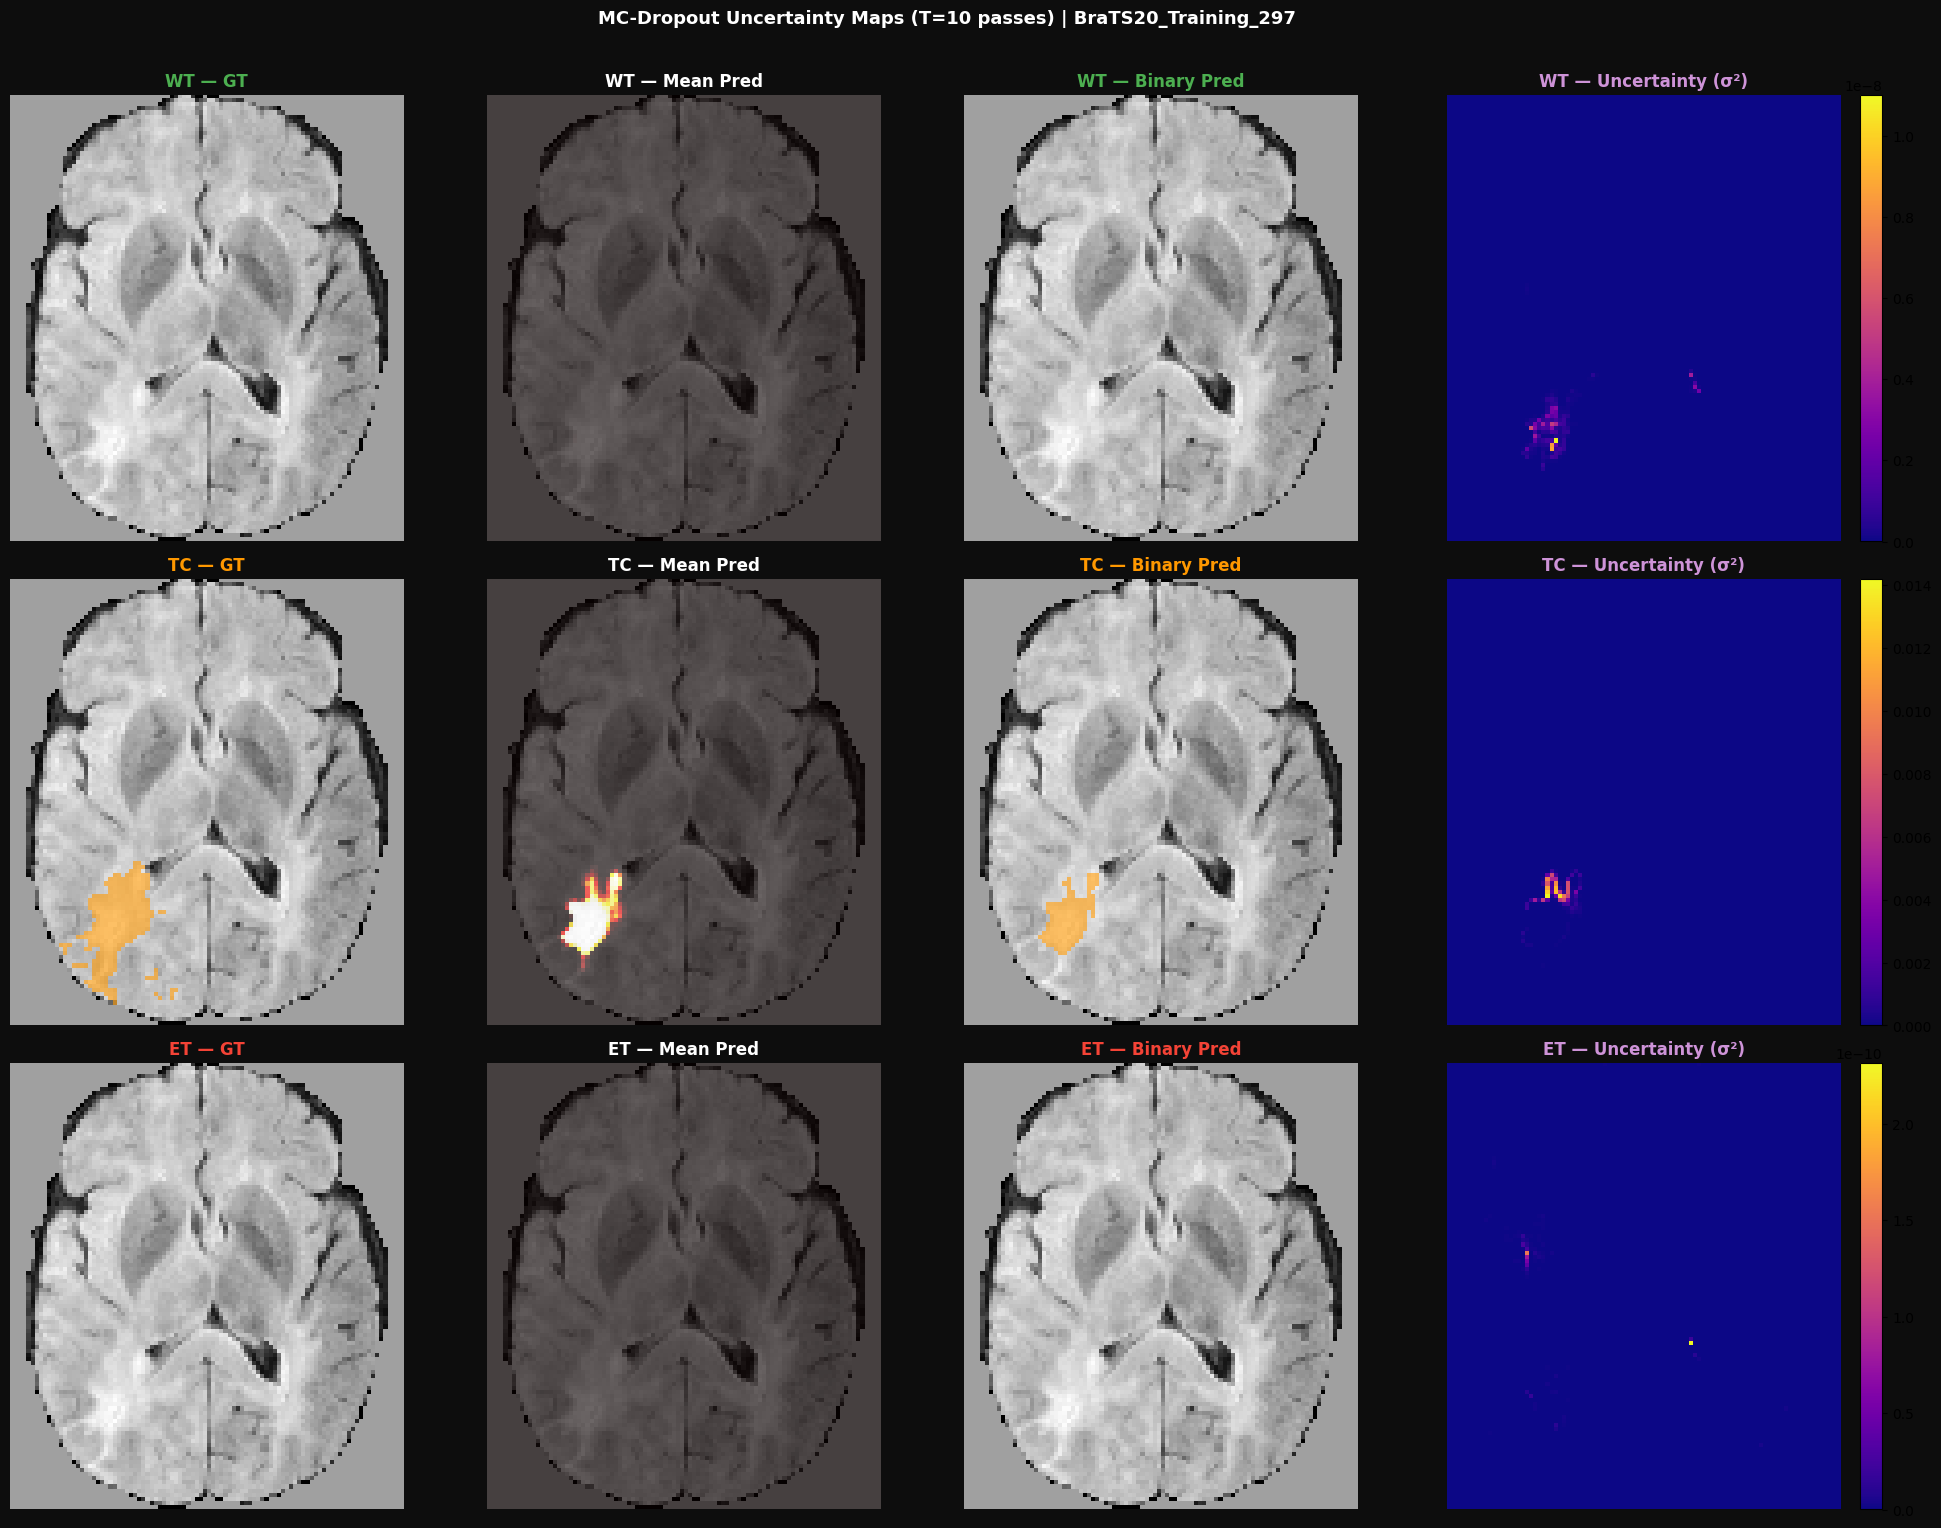

   Global uncertainty stats — Mean: 0.0000, Max: 0.0370


In [24]:
# ============================================================
# CELL 17: Uncertainty Estimation Visualization
# ============================================================
def visualize_uncertainty(model, batch: Dict, device: torch.device, case_id: str = ""):
    """Visualize MC-Dropout uncertainty maps alongside prediction."""
    imgs, segs = batch_to_image_label(batch, device)

    # MC Dropout inference
    mean_pred, uncertainty = model.predict_with_uncertainty(imgs, n_passes=cfg.MC_PASSES)

    img_np   = imgs[0, 0].cpu().numpy()              # FLAIR
    mean_np  = mean_pred[0].cpu().numpy()             # (3, H, W, D)
    unc_np   = uncertainty[0].cpu().numpy()           # (3, H, W, D)
    seg_np   = segs[0].cpu().numpy()

    best_slice = img_np.shape[2] // 2
    bg = img_np[:, :, best_slice].T

    region_names = ["WT", "TC", "ET"]
    colors = ["#4CAF50", "#FF9800", "#F44336"]

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.patch.set_facecolor("#0d0d0d")

    for r, (name, color) in enumerate(zip(region_names, colors)):
        # GT
        axes[r, 0].imshow(bg, cmap="gray", origin="lower")
        gt_mask = np.ma.masked_where(seg_np[r, :, :, best_slice].T == 0,
                                     seg_np[r, :, :, best_slice].T)
        axes[r, 0].imshow(gt_mask, cmap=ListedColormap([color]), origin="lower", alpha=0.6)
        axes[r, 0].set_title(f"{name} — GT", color=color, fontweight="bold")
        axes[r, 0].axis("off")

        # Mean prediction
        axes[r, 1].imshow(bg, cmap="gray", origin="lower")
        pred_slice = mean_np[r, :, :, best_slice].T
        axes[r, 1].imshow(pred_slice, cmap="hot", origin="lower", alpha=0.6, vmin=0, vmax=1)
        axes[r, 1].set_title(f"{name} — Mean Pred", color="white", fontweight="bold")
        axes[r, 1].axis("off")

        # Binarized prediction
        bin_pred = (pred_slice > 0.5).astype(float)
        axes[r, 2].imshow(bg, cmap="gray", origin="lower")
        bin_masked = np.ma.masked_where(bin_pred == 0, bin_pred)
        axes[r, 2].imshow(bin_masked, cmap=ListedColormap([color]), origin="lower", alpha=0.6)
        axes[r, 2].set_title(f"{name} — Binary Pred", color=color, fontweight="bold")
        axes[r, 2].axis("off")

        # Uncertainty map
        unc_slice = unc_np[r, :, :, best_slice].T
        im = axes[r, 3].imshow(unc_slice, cmap="plasma", origin="lower")
        axes[r, 3].set_title(f"{name} — Uncertainty (σ²)", color="#CE93D8", fontweight="bold")
        axes[r, 3].axis("off")
        plt.colorbar(im, ax=axes[r, 3], fraction=0.046, pad=0.04)

    for ax in axes.flat:
        ax.set_facecolor("#111111")

    plt.suptitle(
        f"MC-Dropout Uncertainty Maps (T={cfg.MC_PASSES} passes) | {case_id}",
        color="white", fontsize=13, fontweight="bold", y=1.01
    )
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / f"uncertainty_{case_id}.png", dpi=150,
                bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()
    print(f"   Global uncertainty stats — Mean: {unc_np.mean():.4f}, Max: {unc_np.max():.4f}")


# Visualize uncertainty for first val case
val_batch = next(iter(val_loader))
pid = val_cases[0]["pid"] if val_cases else "case_0"
visualize_uncertainty(model, val_batch, DEVICE, case_id=pid)

   Captured 16 attention layers
   Last layer attn shape: torch.Size([1, 216, 384])


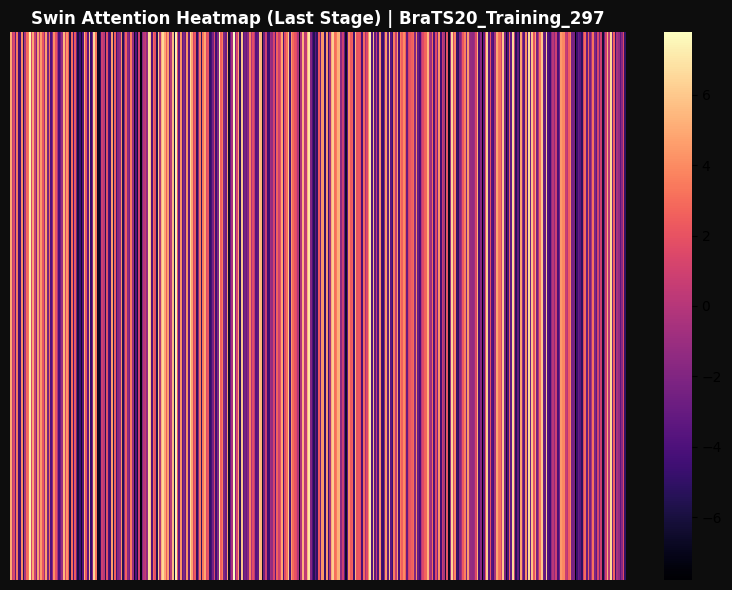

In [25]:
# ============================================================
# CELL 18: Attention Map Extraction & Visualization
# ============================================================
class AttentionExtractor:
    """
    Hook-based attention map extractor for Swin UNETR.
    Registers forward hooks on the attention layers.
    """

    def __init__(self, model: nn.Module):
        self.attention_maps = []
        self.hooks = []
        self._register_hooks(model)

    def _register_hooks(self, model: nn.Module):
        for name, module in model.named_modules():
            # Target WindowAttention layers inside swinViT
            if "attn" in name.lower() and hasattr(module, "relative_position_bias_table"):
                hook = module.register_forward_hook(self._hook_fn)
                self.hooks.append(hook)

    def _hook_fn(self, module, input, output):
        # output is typically (B_windows, heads, N, N)
        if isinstance(output, tuple):
            self.attention_maps.append(output[0].detach().cpu())
        else:
            self.attention_maps.append(output.detach().cpu())

    def clear(self):
        self.attention_maps.clear()

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()
        self.hooks.clear()


def visualize_attention(model, batch: Dict, device: torch.device, case_id: str = ""):
    """Extract and visualize Swin attention for a single case."""
    extractor = AttentionExtractor(model.model)
    imgs, _ = batch_to_image_label(batch, device)

    model.eval()
    extractor.clear()
    with torch.no_grad():
        _ = sliding_window_inference(
            imgs,
            roi_size=cfg.ROI_SIZE,
            sw_batch_size=1,
            predictor=model,
            overlap=0.5,
    )

    extractor.remove_hooks()

    img_np = imgs[0, 0].cpu().numpy()  # FLAIR
    mid_slice = img_np.shape[2] // 2

    if not extractor.attention_maps:
        print("⚠️  No attention maps captured (hooks may need adjustment for this MONAI version)")
        print("   Showing placeholder attention visualization...")

        # Fallback: gradient-based saliency
        imgs_req = imgs.clone().requires_grad_(True)
        model.eval()
        logits = model(imgs_req)
        logits[:, 2].sum().backward()  # ET channel
        saliency = imgs_req.grad[0, 0].abs().cpu().numpy()

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.patch.set_facecolor("#0d0d0d")
        bg = img_np[:, :, mid_slice].T

        axes[0].imshow(bg, cmap="gray", origin="lower")
        axes[0].set_title("FLAIR Input", color="white")
        axes[0].axis("off")

        axes[1].imshow(saliency[:, :, mid_slice].T, cmap="hot", origin="lower")
        axes[1].set_title("Gradient Saliency (ET)", color="#F44336", fontweight="bold")
        axes[1].axis("off")

        axes[2].imshow(bg, cmap="gray", origin="lower", alpha=0.7)
        axes[2].imshow(saliency[:, :, mid_slice].T, cmap="jet", origin="lower", alpha=0.5)
        axes[2].set_title("Overlay", color="white")
        axes[2].axis("off")

        for ax in axes:
            ax.set_facecolor("#0d0d0d")

        plt.suptitle(f"Gradient Saliency Map | {case_id}",
                     color="white", fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.savefig(cfg.OUTPUT_DIR / f"saliency_{case_id}.png", dpi=150,
                    bbox_inches="tight", facecolor="#0d0d0d")
        plt.show()
        return

    # Aggregate attention from last layer
    last_attn = extractor.attention_maps[-1].float()  # (B_w, heads, N, N)
    attn_avg = last_attn.mean(dim=(0, 1))  # (384,)
    attn_2d  = attn_avg.unsqueeze(0)       # (1, 384)

    print(f"   Captured {len(extractor.attention_maps)} attention layers")
    print(f"   Last layer attn shape: {last_attn.shape}")

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.patch.set_facecolor("#0d0d0d")
    ax.set_facecolor("#111111")
    sns.heatmap(
    attn_2d.numpy(),
    ax=ax,
    cmap="magma",
    cbar=True,
    xticklabels=False,
    yticklabels=False,)
    ax.set_title(f"Swin Attention Heatmap (Last Stage) | {case_id}",
                 color="white", fontweight="bold")
    plt.tight_layout()
    plt.savefig(cfg.OUTPUT_DIR / f"attention_{case_id}.png", dpi=150,
                bbox_inches="tight", facecolor="#0d0d0d")
    plt.show()


val_batch = next(iter(val_loader))
pid = val_cases[0]["pid"] if val_cases else "case_0"
visualize_attention(model, val_batch, DEVICE, case_id=pid)

In [27]:
# ============================================================
# CELL 19: Final Quantitative Evaluation on Validation Set
# ============================================================
def compute_full_metrics(model, loader, device) -> pd.DataFrame:
    """Compute per-case, per-class metrics and return as DataFrame."""
    model.eval()
    records = []

    for i, batch in enumerate(tqdm(loader, desc="Evaluating")):
        imgs, segs = batch_to_image_label(batch, device)
        with torch.no_grad(), autocast(device_type=DEVICE.type, enabled=cfg.AMP):
            logits = sliding_window_inference(
            imgs,
            roi_size=cfg.ROI_SIZE,
            sw_batch_size=1,
            predictor=model,
            overlap=0.5,
        )

        preds_bin = (torch.sigmoid(logits) > 0.5).float()
        gt  = segs[0].cpu().numpy()
        pr  = preds_bin[0].cpu().numpy()

        row = {"case": val_cases[i]["pid"] if i < len(val_cases) else f"case_{i}"}
        for ci, region in enumerate(["WT", "TC", "ET"]):
            g = gt[ci].flatten()
            p = pr[ci].flatten()
            tp = (g * p).sum()
            fp = ((1 - g) * p).sum()
            fn = (g * (1 - p)).sum()
            tn = ((1 - g) * (1 - p)).sum()

            dice = 2 * tp / (2 * tp + fp + fn + 1e-6)
            iou  = tp / (tp + fp + fn + 1e-6)
            sens = tp / (tp + fn + 1e-6)
            spec = tn / (tn + fp + 1e-6)

            row[f"dice_{region}"] = float(dice)
            row[f"iou_{region}"]  = float(iou)
            row[f"sens_{region}"] = float(sens)
            row[f"spec_{region}"] = float(spec)

        records.append(row)

    return pd.DataFrame(records)


results_df = compute_full_metrics(model, val_loader, DEVICE)
results_df.to_csv(cfg.OUTPUT_DIR / "val_metrics.csv", index=False)

# Summary statistics
metric_cols = [c for c in results_df.columns if c != "case"]
summary = results_df[metric_cols].agg(["mean", "std", "median"])

print("\n" + "="*70)
print(" 📊 FINAL VALIDATION METRICS")
print("="*70)
for region in ["WT", "TC", "ET"]:
    d  = summary.loc["mean", f"dice_{region}"]
    ds = summary.loc["std",  f"dice_{region}"]
    io = summary.loc["mean", f"iou_{region}"]
    se = summary.loc["mean", f"sens_{region}"]
    sp = summary.loc["mean", f"spec_{region}"]
    print(f" {region:3s}  Dice: {d:.3f}±{ds:.3f} | IoU: {io:.3f} | Sens: {se:.3f} | Spec: {sp:.3f}")
print("="*70)

mean_dice = summary.loc["mean", ["dice_WT", "dice_TC", "dice_ET"]].mean()
print(f" Mean Dice (WT/TC/ET): {mean_dice:.4f}")
print("="*70)

Evaluating:   0%|          | 0/55 [00:00<?, ?it/s]


 📊 FINAL VALIDATION METRICS
 WT   Dice: 0.864±0.153 | IoU: 0.785 | Sens: 0.869 | Spec: 0.999
 TC   Dice: 0.917±0.054 | IoU: 0.851 | Sens: 0.922 | Spec: 0.998
 ET   Dice: 0.738±0.261 | IoU: 0.635 | Sens: 0.770 | Spec: 0.999
 Mean Dice (WT/TC/ET): 0.8395


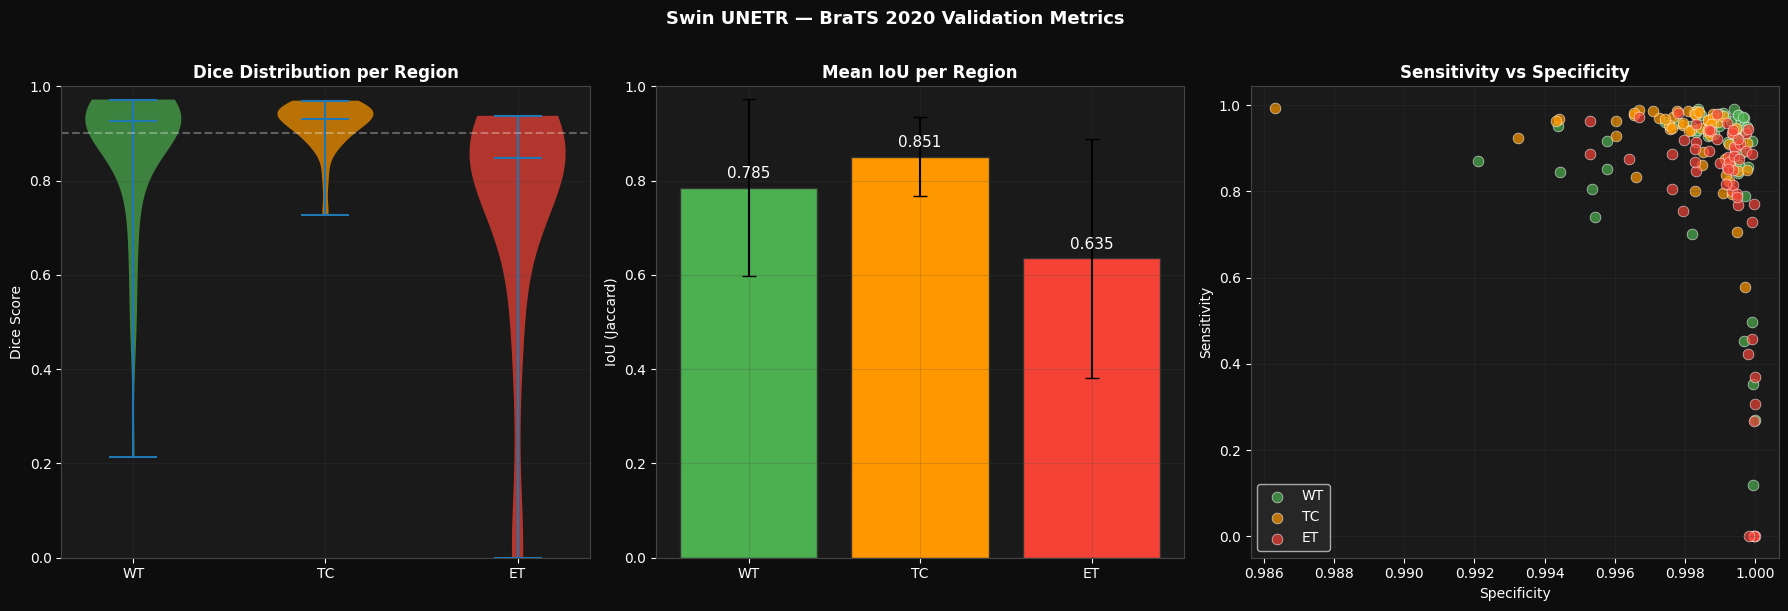

In [28]:
# ============================================================
# CELL 20: Metrics Visualization (Violin + Scatter plots)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0d0d0d")

for ax in axes:
    ax.set_facecolor("#1a1a1a")
    ax.grid(True, alpha=0.2, color="#444")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")

region_colors = {"WT": "#4CAF50", "TC": "#FF9800", "ET": "#F44336"}

# Dice violin
dice_data = {r: results_df[f"dice_{r}"].values for r in ["WT", "TC", "ET"]}
parts = axes[0].violinplot(list(dice_data.values()), positions=[1, 2, 3], showmedians=True)
for pc, color in zip(parts["bodies"], ["#4CAF50", "#FF9800", "#F44336"]):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(["WT", "TC", "ET"], color="white")
axes[0].set_ylabel("Dice Score", color="white")
axes[0].set_title("Dice Distribution per Region", color="white", fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].axhline(0.9, color="white", ls="--", alpha=0.3)

# IoU bar
iou_means = [results_df[f"iou_{r}"].mean() for r in ["WT", "TC", "ET"]]
iou_stds  = [results_df[f"iou_{r}"].std()  for r in ["WT", "TC", "ET"]]
bars = axes[1].bar(["WT", "TC", "ET"], iou_means,
                    color=["#4CAF50", "#FF9800", "#F44336"],
                    yerr=iou_stds, capsize=5, edgecolor="#333")
axes[1].set_ylabel("IoU (Jaccard)", color="white")
axes[1].set_title("Mean IoU per Region", color="white", fontweight="bold")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, iou_means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", color="white", fontsize=11)

# Sensitivity vs Specificity scatter
for r, color in region_colors.items():
    axes[2].scatter(
        results_df[f"spec_{r}"], results_df[f"sens_{r}"],
        label=r, color=color, alpha=0.7, s=60, edgecolors="white", linewidths=0.5
    )
axes[2].set_xlabel("Specificity", color="white")
axes[2].set_ylabel("Sensitivity", color="white")
axes[2].set_title("Sensitivity vs Specificity", color="white", fontweight="bold")
axes[2].legend(facecolor="#2a2a2a", labelcolor="white")

plt.suptitle("Swin UNETR — BraTS 2020 Validation Metrics",
             color="white", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "final_metrics.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()

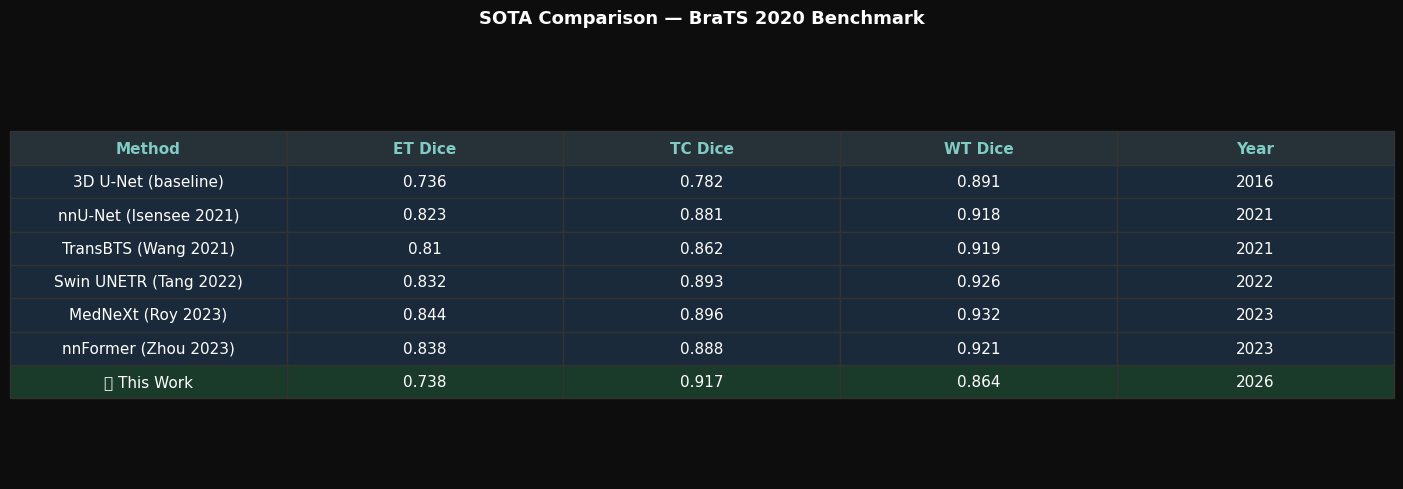

In [29]:
# ============================================================
# CELL 21: SOTA Comparison
# ============================================================
sota_data = {
    "Method": [
        "3D U-Net (baseline)",
        "nnU-Net (Isensee 2021)",
        "TransBTS (Wang 2021)",
        "Swin UNETR (Tang 2022)",
        "MedNeXt (Roy 2023)",
        "nnFormer (Zhou 2023)",
        "🔵 This Work",
    ],
    "ET Dice": [0.736, 0.823, 0.810, 0.832, 0.844, 0.838, None],
    "TC Dice": [0.782, 0.881, 0.862, 0.893, 0.896, 0.888, None],
    "WT Dice": [0.891, 0.918, 0.919, 0.926, 0.932, 0.921, None],
    "Year":    [2016, 2021, 2021, 2022, 2023, 2023, 2026],
}

# Fill in our results
if not results_df.empty:
    sota_data["ET Dice"][-1] = round(results_df["dice_ET"].mean(), 3)
    sota_data["TC Dice"][-1] = round(results_df["dice_TC"].mean(), 3)
    sota_data["WT Dice"][-1] = round(results_df["dice_WT"].mean(), 3)
else:
    sota_data["ET Dice"][-1] = "—"
    sota_data["TC Dice"][-1] = "—"
    sota_data["WT Dice"][-1] = "—"

sota_df = pd.DataFrame(sota_data)

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")
ax.axis("off")

col_labels = sota_df.columns.tolist()
cell_text  = sota_df.values.tolist()
colors_row = [["#1a2a3a"] * len(col_labels)] * (len(sota_df) - 1) + [["#1a3a2a"] * len(col_labels)]

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc="center",
    loc="center",
    cellColours=colors_row,
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_text_props(color="white")
    cell.set_edgecolor("#333")
    if row == 0:
        cell.set_facecolor("#263238")
        cell.set_text_props(color="#80CBC4", fontweight="bold")

ax.set_title("SOTA Comparison — BraTS 2020 Benchmark",
             color="white", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig(cfg.OUTPUT_DIR / "sota_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0d0d0d")
plt.show()